In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# Load the data directly from the URL
url = "https://raw.githubusercontent.com/shrikant-temburwar/Loan-Prediction-Dataset/master/train.csv"
df = pd.read_csv(url)

# Clean missing data
df = df.dropna()
print("Data loaded and cleaned successfully!")

Data loaded and cleaned successfully!


In [3]:
# Convert text categories to numbers
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
df['Married'] = df['Married'].map({'Yes': 1, 'No': 0})
df['Education'] = df['Education'].map({'Graduate': 1, 'Not Graduate': 0})
df['Self_Employed'] = df['Self_Employed'].map({'Yes': 1, 'No': 0})
df['Property_Area'] = df['Property_Area'].map({'Urban': 2, 'Semiurban': 1, 'Rural': 0})
df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})

# Select Features and Target
features = ['Gender', 'Married', 'Education', 'Self_Employed', 'ApplicantIncome', 'LoanAmount', 'Credit_History', 'Property_Area']
X = df[features]
y = df['Loan_Status']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Data successfully prepared and split!")

Data successfully prepared and split!


In [4]:
# Initialize and Train the model
model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train, y_train)

# Check accuracy
accuracy = model.score(X_test, y_test)
print(f"📈 Test Accuracy: {accuracy * 100:.2f}%")

📈 Test Accuracy: 77.08%


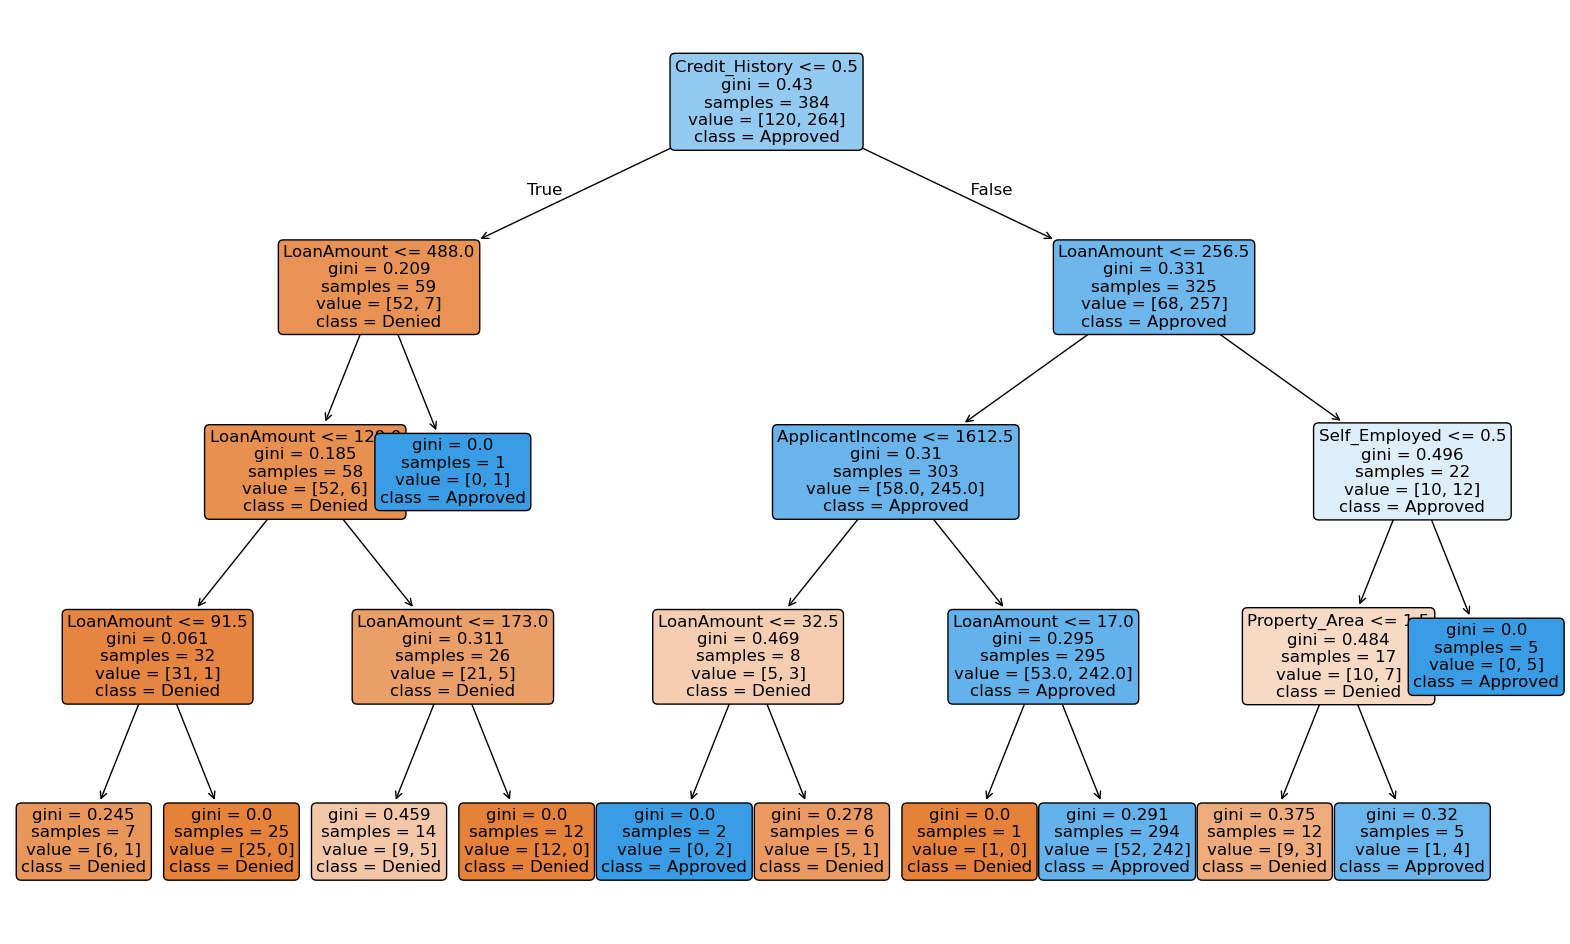

In [5]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# 1. Set the size of your display image (Width, Height in inches)
plt.figure(figsize=(20, 12))

# 2. Plot the tree with beautiful visuals and text labels
plot_tree(model, 
          feature_names=features, 
          class_names=['Denied', 'Approved'], 
          filled=True, 
          rounded=True, 
          fontsize=12)

# 3. Show the final graph
plt.show()

In [6]:
# 1. Define custom data: [Gender, Married, Education, Self_Employed, ApplicantIncome, LoanAmount, Credit_History, Property_Area]
my_custom_profile = [[1, 0, 1, 1, 6000, 150, 1.0, 1]] 

# 2. Convert it into a temporary DataFrame with the exact feature names
my_custom_df = pd.DataFrame(my_custom_profile, columns=features)

# 3. Predict using the trained model
prediction = model.predict(my_custom_df)

if prediction[0] == 1:
    print("🎉 AI Decision: Loan APPROVED!")
else:
    print("❌ AI Decision: Loan DENIED!")

🎉 AI Decision: Loan APPROVED!
